# Question 1

In [225]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import matplotlib.ticker as ticker
import numpy as np
import re
from pathlib import Path
import json
from matplotlib.patches import Patch
import urllib.parse
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib as mpl

In [226]:
def load_mcperf_file(filename, tc_combination):
    valid_lines = []

    with open(filename, "r") as f:
        for line in f:
            # Keep header and data lines only
            if line.startswith("#") or line.startswith("read"):
                valid_lines.append(line)

    # Read filtered lines into pandas
    from io import StringIO

    df = pd.read_csv(
        StringIO("".join(valid_lines)),
        delim_whitespace=True
    )

    df = df[["target", "QPS", "p95"]]

    tc_combination = tc_combination.replace("_", " ")

    df["combination"] = tc_combination

    return df

In [227]:
# load_mcperf_file("results/q1/T1_C1/2026-04-04_12:52:03/mcperf.txt", "T1_C1")

In [228]:
path_name = "results/q1"
all_dfs = []
root_dir = Path(path_name)

for subdir in root_dir.iterdir():
    combination_name = subdir.name

    # Walk through all nested directories
    for nested_dir in subdir.rglob("*"):
        if not nested_dir.is_dir():
            continue

        # If this nested directory contains CSV files → skip it
        if "T3" not in combination_name:
            if any(nested_dir.glob("*.csv")):
                continue
        else:
            if not any(nested_dir.glob("*.csv")):
                continue

        # Otherwise process files inside it
        for file in nested_dir.glob("*.txt"):
            if file.is_file():
                df = load_mcperf_file(str(file), combination_name)
                all_dfs.append(df)

all_measurements = pd.concat(all_dfs)
all_measurements["p95"] = all_measurements["p95"]/1000
all_measurements

/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/3913560490.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/3913560490.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/3913560490.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/3913560490.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9

,target,QPS,p95,combination
0,5000,4892.5,0.3577,T3 C1
1,15000,14835.9,0.3827,T3 C1
2,25000,25033.0,0.4523,T3 C1
3,35000,34958.5,0.4988,T3 C1
4,45000,45085.0,0.5641,T3 C1
...,...,...,...,...
8,85000,69096.3,1.6607,T1 C1
9,95000,70040.5,1.6366,T1 C1
10,105000,66031.8,1.7431,T1 C1
11,115000,64161.3,1.8011,T1 C1


In [229]:
result = (
    all_measurements
    .groupby(["combination", "target"])
    .agg({
        "QPS": ["mean", "std"],
        "p95": ["mean", "std"]
    })
    .reset_index()
)

result.columns = [
    "_".join(col).strip("_")
    for col in result.columns
]

result

,combination,target,QPS_mean,QPS_std,p95_mean,p95_std
0,T1 C1,5000,4908.833333,20.008332,0.369167,0.031582
1,T1 C1,15000,14959.500000,174.071824,0.438633,0.028942
2,T1 C1,25000,24916.466667,58.287248,0.475633,0.011962
3,T1 C1,35000,34824.500000,222.057988,0.493667,0.015668
4,T1 C1,45000,45008.166667,113.783054,0.530767,0.015003
...,...,...,...,...,...,...
112,T3 C3,85000,84932.133333,170.246889,0.444267,0.008451
113,T3 C3,95000,94814.900000,332.877200,0.471633,0.028437
114,T3 C3,105000,105189.466667,197.071214,0.474400,0.026546
115,T3 C3,115000,114910.766667,116.393313,0.558133,0.097066


/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/2401745507.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


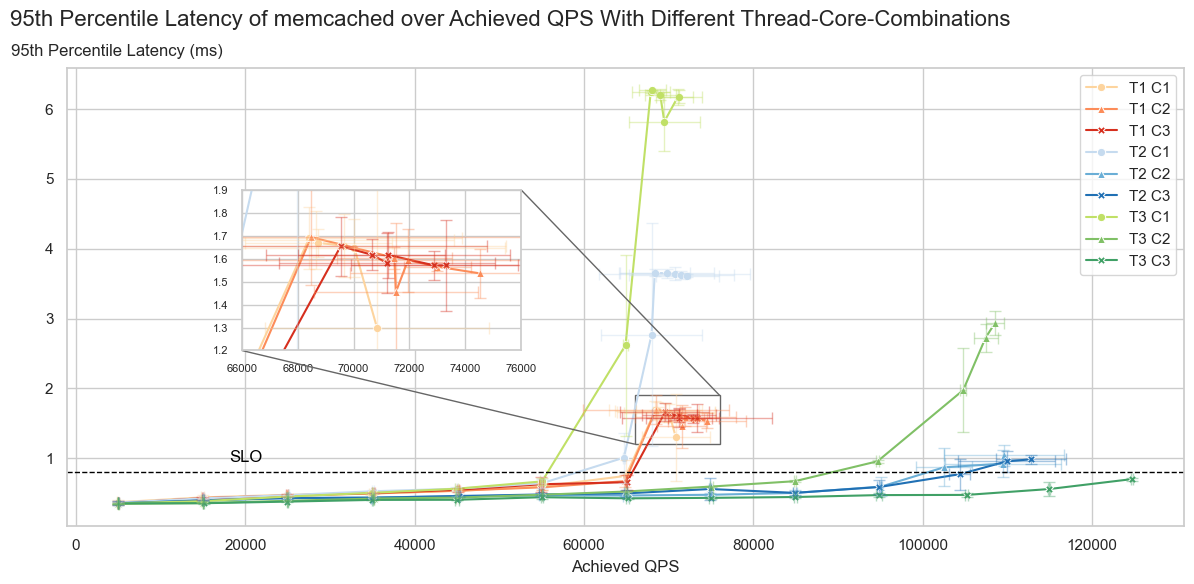

In [230]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

markers = {
    "T1 C1": "o",
    "T1 C2": "^",
    "T1 C3": "X",
    "T2 C1": "o",
    "T2 C2": "^",
    "T2 C3": "X",
    "T3 C1": "o",
    "T3 C2": "^",
    "T3 C3": "X",
}

# Generate shades
blue_shades = sns.color_palette("OrRd", 3)
pink_shades = sns.color_palette("Blues", 3)
green_shades = sns.color_palette("summer", 3)

colors = {
    "T1 C1": blue_shades[0],
    "T1 C2": blue_shades[1],
    "T1 C3": blue_shades[2],

    "T2 C1": pink_shades[0],
    "T2 C2": pink_shades[1],
    "T2 C3": pink_shades[2],

    "T3 C1": green_shades[2],
    "T3 C2": green_shades[1],
    "T3 C3": green_shades[0],
}

combinations = sorted(result["combination"].unique())
palette = dict(zip(
    combinations,
    sns.color_palette("tab10", len(combinations))
))

ax = sns.lineplot(
    data=result,
    x="QPS_mean",
    y="p95_mean",
    hue="combination",
    style="combination",
    markers=markers,
    dashes=False,
    markersize=6,
    palette=colors
)

for combination, df_group in result.groupby("combination"):
    ax.errorbar(
        df_group["QPS_mean"],
        df_group["p95_mean"],
        xerr=df_group["QPS_std"],    # std for QPS
        yerr=df_group["p95_std"],    # std for p95
        fmt="none",                 # no extra marker
        capsize=4,
        elinewidth=1,
        alpha=0.4,
        color=colors[combination]
    )

ax.axhline(
    y=0.8,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.text(
    20000,          # x-position
    0.90,        # y-position
    "SLO",
    color="black",
    ha="center",
    va="bottom",
    fontsize=12
)

handles, labels = plt.gca().get_legend_handles_labels()

# Sort alphabetically by label
sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0])

labels, handles = zip(*sorted_pairs)

plt.legend(handles, labels)

####### zoomin #######
# Create zoom inset
axins = inset_axes(
    ax,
    width="25%",
    height="35%",
    loc="upper left",
    bbox_to_anchor=(0.15, -0.25, 1, 1),
    bbox_transform=ax.transAxes,
)

# Replot same data inside inset
sns.lineplot(
    data=result,
    x="QPS_mean",
    y="p95_mean",
    hue="combination",
    style="combination",
    markers=markers,
    dashes=False,
    markersize=6,
    palette=colors,
    ax=axins,
    legend=False
)

# Add error bars to inset
for combination, df_group in result.groupby("combination"):
    axins.errorbar(
        df_group["QPS_mean"],
        df_group["p95_mean"],
        xerr=df_group["QPS_std"],
        yerr=df_group["p95_std"],
        fmt="none",
        capsize=4,
        elinewidth=1,
        alpha=0.4,
        color=colors[combination]
    )

# Zoom area
axins.set_xlim(66000, 76000)
axins.set_ylim(1.2, 1.9)

axins.axhline(
    y=0.8,
    color="black",
    linestyle="--",
    linewidth=1
)

axins.set_xlabel("")
axins.set_ylabel("")
axins.tick_params(labelsize=8)

# Draw rectangle + connection lines on main plot
mark_inset(
    ax,
    axins,
    loc1=1,
    loc2=3,
    fc="none",
    ec="0.4",
    linewidth=1
)
###############

ax.set_xlabel("Achieved QPS")
ax.set_ylabel(
    "95th Percentile Latency (ms)",
    rotation=0,     # horizontal
    labelpad=60,    # move away from axis
    ha="left",
    va="bottom"
)

ax.set_title(
    "95th Percentile Latency of memcached over Achieved QPS With Different Thread-Core-Combinations",
    fontsize=16,
    pad=30,
    x=0.397
)

ax.yaxis.set_label_coords(-0.05, 1.02)

plt.tight_layout()
plt.savefig("results/q1/plot1.pdf", bbox_inches="tight")
plt.show()

# Question 2

In [231]:
def load_mcperf_file(filename, tc_combination):
    valid_lines = []

    with open(filename, "r") as f:
        for line in f:
            # Keep header and data lines only
            if line.startswith("#") or line.startswith("read"):
                valid_lines.append(line)

    # Read filtered lines into pandas
    from io import StringIO

    df = pd.read_csv(
        StringIO("".join(valid_lines)),
        delim_whitespace=True
    )

    df = df[["target", "QPS", "p95", "ts_start", "ts_end"]]

    tc_combination = tc_combination.replace("_", " ")

    df["combination"] = tc_combination

    df["p95"] = df["p95"] / 1000

    return df

In [232]:
path_name = "results/q1"
all_dfs = []
root_dir = Path(path_name)

for subdir in root_dir.iterdir():
    combination_name = subdir.name
    
    # Only find CSV files
    files = [f for f in subdir.rglob("*.csv") if f.is_file()]

    for file in files:
        df = pd.read_csv(file)
        df["combination"] = combination_name
        all_dfs.append(df)

cpu_measurements = pd.concat(all_dfs)

cpu_measurements

,timestamp,cpu0,cpu1,cpu2,cpu3,combination
0,2026-05-04T16:06:34.795428,5.0,5.1,6.0,2.0,T3_C1
1,2026-05-04T16:06:35.795863,0.0,7.1,1.0,1.0,T3_C1
2,2026-05-04T16:06:36.796257,1.0,1.0,1.0,2.0,T3_C1
3,2026-05-04T16:06:37.796641,4.0,1.0,3.0,4.1,T3_C1
4,2026-05-04T16:06:38.797041,2.0,0.0,0.0,0.0,T3_C1
...,...,...,...,...,...,...
51,2026-05-04T16:12:27.943157,64.4,55.7,69.3,12.7,T3_C3
52,2026-05-04T16:12:28.943525,0.0,1.0,1.0,0.0,T3_C3
53,2026-05-04T16:12:29.944151,57.0,55.4,52.5,9.2,T3_C3
54,2026-05-04T16:12:30.944907,96.1,96.0,91.3,15.6,T3_C3


In [233]:
path_name = "results/q1"
all_dfs = []
root_dir = Path(path_name)

for subdir in root_dir.iterdir():
    combination_name = subdir.name
    combination_dfs = []

    # Walk through all nested directories
    for nested_dir in subdir.rglob("*"):
        if not nested_dir.is_dir():
            continue

        # If this nested directory contains CSV files → skip it
        if not any(nested_dir.glob("*.csv")):
            continue

        # Otherwise process files inside it
        for file in nested_dir.glob("*.txt"):
            # print(file)
            if file.is_file():
                mcperf_df = load_mcperf_file(str(file), combination_name)
        
        for file in nested_dir.glob("*.csv"):
            # print(file)
            if file.is_file():
                cpu_df = pd.read_csv(file)
                cpu_df["combination"] = combination_name

        mcperf_df["ts_start"] = pd.to_datetime(mcperf_df["ts_start"], unit="ms")
        mcperf_df["ts_end"] = pd.to_datetime(mcperf_df["ts_end"], unit="ms")
        cpu_df["timestamp"] = pd.to_datetime(cpu_df["timestamp"])

        # Choose cores based on combination name
        if "C1" in combination_name:
            cpu_cols = ["cpu0"]
        elif "C2" in combination_name:
            cpu_cols = ["cpu0", "cpu1"]
        elif "C3" in combination_name:
            cpu_cols = ["cpu0", "cpu1", "cpu2"]
        else:
            raise ValueError(f"Unknown core combination in {combination_name}")

        # Sum only the selected cores at each timestamp
        cpu_df["cpu_sum"] = cpu_df[cpu_cols].sum(axis=1)

        rows = []

        for _, row in mcperf_df.iterrows():

            cpu_window = cpu_df[
                (cpu_df["timestamp"] >= row["ts_start"]) &
                (cpu_df["timestamp"] <= row["ts_end"])
            ]

            rows.append({
                "QPS": row["QPS"],
                "target": row["target"],
                "p95": row["p95"],
                "combination": row["combination"],

                # peak selected CPU usage
                "cpu_total_max": cpu_window["cpu_sum"].max(),

                "num_samples": len(cpu_window)
            })

        qps_cpu = pd.DataFrame(rows)
        combination_dfs.append(qps_cpu)
    
    if (combination_dfs):
        combination_df = pd.concat(combination_dfs)
        all_dfs.append(combination_df)


/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/4287394795.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/4287394795.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/4287394795.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/4287394795.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/b8/_jp9

In [234]:
all_dfs[2]

,QPS,target,p95,combination,cpu_total_max,num_samples
0,4996.5,5000,0.3588,T3 C3,6.5,2
1,15049.0,15000,0.3576,T3 C3,24.3,3
2,24862.9,25000,0.3727,T3 C3,61.3,2
3,35084.5,35000,0.3996,T3 C3,105.2,2
4,44758.7,45000,0.4089,T3 C3,134.8,2
5,55000.0,55000,0.4273,T3 C3,162.4,3
6,65242.5,65000,0.4309,T3 C3,180.6,2
7,75029.0,75000,0.4242,T3 C3,193.8,2
8,85055.5,85000,0.4408,T3 C3,210.8,3
9,95017.0,95000,0.4534,T3 C3,231.7,2


In [235]:
all_results = []

for df in all_dfs:
    result = (
        df
        .groupby(["combination", "target"])
        .agg({
            "QPS": ["mean", "std"],
            "p95": ["mean", "std"],
            "cpu_total_max": ["mean", "std"]
        })
        .reset_index()
    )

    result.columns = [
        "_".join(col).strip("_")
        for col in result.columns
    ]

    all_results.append(result)

all_results[0]

,combination,target,QPS_mean,QPS_std,p95_mean,p95_std,cpu_total_max_mean,cpu_total_max_std
0,T3 C1,5000,4914.833333,37.390953,0.354000,0.004857,4.100000,0.608276
1,T3 C1,15000,14879.133333,70.935910,0.383967,0.005314,19.333333,2.150194
2,T3 C1,25000,24940.833333,111.079176,0.450367,0.001950,48.933333,1.514376
3,T3 C1,35000,34989.500000,27.013885,0.504167,0.013477,64.133333,1.761628
4,T3 C1,45000,44933.633333,154.648321,0.562833,0.003859,75.766667,1.386843
5,T3 C1,55000,55030.800000,235.931600,0.667900,0.044698,86.733333,2.157159
6,T3 C1,65000,64890.733333,342.683664,2.618767,1.295970,99.000000,1.000000
7,T3 C1,75000,69468.500000,4190.150726,5.819200,0.417460,100.000000,0.000000
8,T3 C1,85000,71234.433333,2691.584805,6.178367,0.091397,100.000000,0.000000
9,T3 C1,95000,71056.266667,1764.626619,6.171167,0.120958,100.000000,0.000000


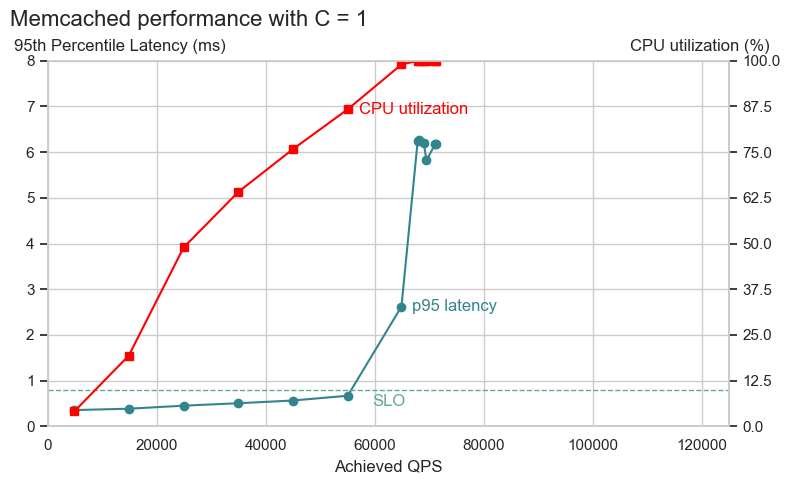

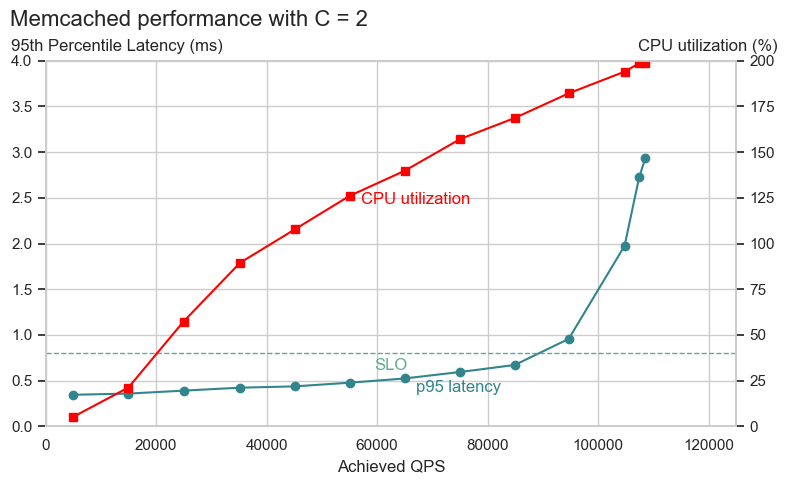

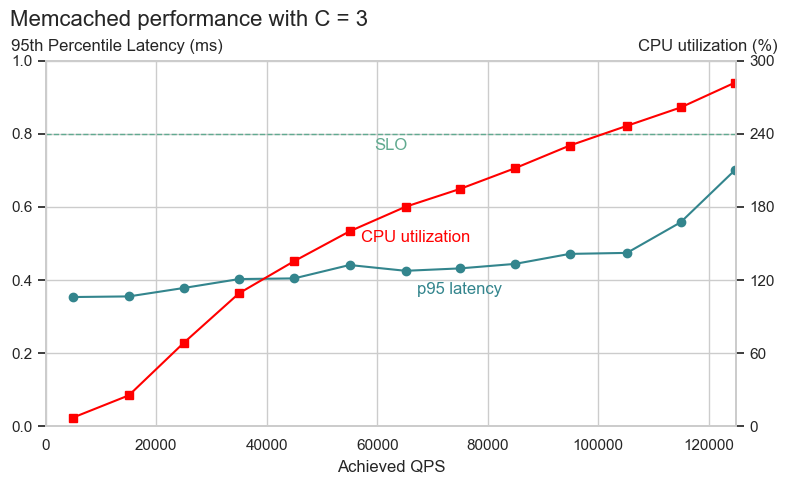

In [236]:
dfs = {
    1: all_results[0],
    2: all_results[1],
    3: all_results[2],
}

blue_shades = sns.color_palette("crest", 3)

for C, df in dfs.items():
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Sort by achieved QPS so lines are drawn correctly
    df_plot = df.sort_values("QPS_mean")

    x = df_plot["QPS_mean"]
    latency = df_plot["p95_mean"]
    cpu = df_plot["cpu_total_max_mean"]

    # Left y-axis: p95 latency
    ax1.plot(x, latency, marker="o", label="p95 latency", color=blue_shades[-2])

    # latency SLO
    ax1.axhline(
        y=0.8,
        color=blue_shades[0],
        linestyle="--",
        linewidth=1
    )

    y_value_text = 0
    if C == 3:
        y_value_text = 0.79
    elif C == 1:
        y_value_text = 0.7
    else:
        y_value_text = 0.75

    ax1.text(
        62500,          # x-position
        y_value_text,        # y-position
        "SLO",
        color=blue_shades[0],
        ha="center",
        va="top",
        fontsize=12
    )

    ax1.set_xlabel("Achieved QPS")
    ax1.set_ylabel(
        "95th Percentile Latency (ms)",
        rotation=0,     # horizontal
        labelpad=60,    # move away from axis
        ha="left",
        va="bottom"
    )
    ax1.yaxis.set_label_coords(-0.05, 1.02)
    ax1.set_xlim(0, 125_000)

    # Right y-axis: CPU utilization
    ax2 = ax1.twinx()
    ax2.plot(x, cpu, marker="s", label="CPU utilization", color="red")
    # ax2.set_ylabel("CPU utilization (%)")
    ax2.set_ylabel(
        "CPU utilization (%)",
        rotation=0,     # horizontal
        labelpad=60,    # move away from axis
        ha="right",
        va="bottom"
    )
    ax2.yaxis.set_label_coords(1.06, 1.02)
    ax2.set_ylim(0, C * 100)

    # Title
    # ax1.set_title(f"Memcached performance with C = {C}")
    ax1.set_title(
        f"Memcached performance with C = {C}",
        fontsize=16,
        pad=25,
        x=0.2075
    )

    # Combined legend from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # ax1.legend(
    #     lines_1 + lines_2,
    #     labels_1 + labels_2,
    #     loc="upper left"
    # )

    if C == 1:
        cpy_loc = 0
        latency_loc = 0
    elif C == 2:
        cpy_loc = 2
        latency_loc = 0.1
    else:
        cpy_loc = 5
        latency_loc = 0.05

    ax1.text(
        x.iloc[6] + 2000,
        latency.iloc[6] - latency_loc,
        "p95 latency",
        color=ax1.lines[0].get_color(),
        va="center"
    )

    # Label CPU line
    ax2.text(
        x.iloc[5] + 2000,
        cpu.iloc[5] - cpy_loc,
        "CPU utilization",
        color=ax2.lines[0].get_color(),
        va="center"
    )

    ##### align the ticks of both axis #####
    if C == 1:
        y_limit = 8
    elif C == 2:
        y_limit = 4
    else:
        y_limit = 1

    ax1.set_ylim(0, y_limit)

    # Choose left-axis ticks
    left_ticks = ax1.get_yticks()
    ax1.set_yticks(left_ticks)

    # Right axis
    ax2.set_ylim(0, 100*C)

    # Map left tick positions proportionally onto right axis
    left_min, left_max = ax1.get_ylim()
    right_min, right_max = ax2.get_ylim()

    right_ticks = (
        (left_ticks - left_min) / (left_max - left_min)
        * (right_max - right_min)
        + right_min
    )

    ax2.set_yticks(right_ticks)

    #############

    ax1.grid(True)
    ax2.grid(False)
    plt.tight_layout()
    plt.savefig(f"results/q1/plotC_{C}.pdf", bbox_inches="tight")
    plt.show()

# Question 3

## Set Path

In [398]:
path = "results/q3/oliver-v2/2026-05-10_13:48:42"
mcperf_path = path + "/mcperf.txt"
plotting_path = path + "/plot.pdf"
# log_files = glob.glob(search_pattern)
# if log_files is None:
#     raise Exception("No log file found in this directory.")
# log_file = log_files[0]
log_file = path + "/log20260510_110455.txt"

In [399]:
# read cpu usage:

rows = []

with open(log_file, "r") as f:
    for line in f:
        decoded = urllib.parse.unquote_plus(line)

        if "[monitor]" not in decoded:
            continue

        timestamp = decoded.split()[0]

        match = re.search(r"\[monitor\]\s*\[(.*?)\]", decoded)

        if match:
            cpu_list = match.group(1)

            cpus = [
                int(cpu.replace("%", "").replace("'", "").strip())
                for cpu in cpu_list.split(",")
            ]

            rows.append([timestamp] + cpus)

cpu_df = pd.DataFrame(
    rows,
    columns=["timestamp", "cpu1", "cpu2", "cpu3", "cpu4"]
)

cpu_df["timestamp"] = pd.to_datetime(cpu_df["timestamp"])
cpu_df["timestamp_ms"] = (cpu_df["timestamp"].astype("int64") / 1000000).astype("int")

cpu_df

,timestamp,cpu1,cpu2,cpu3,cpu4,timestamp_ms
0,2026-05-10 11:04:56.879675,0,0,0,100,1778411096879
1,2026-05-10 11:04:57.356290,3,41,0,62,1778411097356
2,2026-05-10 11:04:57.707653,0,83,100,23,1778411097707
3,2026-05-10 11:04:58.008435,3,100,100,0,1778411098008
4,2026-05-10 11:04:58.309182,19,100,100,57,1778411098309
...,...,...,...,...,...,...
3723,2026-05-10 11:23:42.787964,44,100,47,100,1778412222787
3724,2026-05-10 11:23:43.088745,38,100,42,100,1778412223088
3725,2026-05-10 11:23:43.389454,27,100,27,100,1778412223389
3726,2026-05-10 11:23:43.726720,40,100,100,100,1778412223726


In [400]:
# read jobs on cpus

rows = []

with open(log_file, "r") as f:
    lines = f.readlines()

# skip first and last line
for line in lines[1:-1]:
    line = line.strip()

    # skip encoded CPU monitor lines
    if "%5Bmonitor%5D" in line or "[monitor]" in line:
        continue

    # split timestamp from the rest
    timestamp, rest = line.split(maxsplit=1)

    # Match:
    # start radix [1] 1
    # update_cores memcached [0,2,3]
    # pause barnes
    # end radix
    match = re.match(r"([A-Za-z_]+)\s+([A-Za-z0-9_-]+)(?:\s+(\[[^\]]*\]))?", rest)

    if match:
        event = match.group(1)
        job = match.group(2)
        cores = match.group(3) if match.group(3) else ""

        rows.append([timestamp, event, job, cores])

events_df = pd.DataFrame(
    rows,
    columns=["timestamp", "event", "job", "cores"]
)

events_df["timestamp"] = pd.to_datetime(events_df["timestamp"])
events_df["timestamp_ms"] = (events_df["timestamp"].astype("int64") / 1000000).astype("int")

events_df

,timestamp,event,job,cores,timestamp_ms
0,2026-05-10 11:04:56.426119,update_cores,memcached,"[0,1,2]",1778411096426
1,2026-05-10 11:04:56.426173,start,memcached,"[0, 1, 2]",1778411096426
2,2026-05-10 11:04:56.578654,start,radix,[3],1778411096578
3,2026-05-10 11:04:56.899631,update_cores,memcached,"[0,2]",1778411096899
4,2026-05-10 11:04:56.916100,pause,radix,,1778411096916
...,...,...,...,...,...
135,2026-05-10 11:23:28.342607,update_cores,vips,"[1,3]",1778412208342
136,2026-05-10 11:23:43.408574,update_cores,memcached,[0],1778412223408
137,2026-05-10 11:23:43.426173,update_cores,vips,"[1,2,3]",1778412223426
138,2026-05-10 11:23:44.027470,end,vips,,1778412224027


In [401]:
def load_mcperf_file(filename):
    valid_lines = []

    timestamp_start = 0
    interval = 15000

    with open(filename, "r") as f:
        for line in f:
            if line.startswith("Timestamp start:"):
                timestamp_start = int(line.split(" ")[-1])
            # Keep header and data lines only
            if line.startswith("#") or line.startswith("read"):
                valid_lines.append(line)

    # Read filtered lines into pandas
    from io import StringIO

    df = pd.read_csv(
        StringIO("".join(valid_lines)),
        delim_whitespace=True
    )

    df = df[["target", "QPS", "p95"]]

    df["p95"] = (df["p95"] / 1000)

    df["timestamp_ms"] = [
        timestamp_start + i * interval
        for i in range(len(df))
    ]

    return df

mcperf_df = load_mcperf_file(mcperf_path)
mcperf_df

/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48502/1548391309.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,target,QPS,p95,timestamp_ms
0,6927,6954.3,0.3405,1778411097723
1,52892,52894.2,0.4859,1778411112723
2,98921,98877.6,0.4354,1778411127723
3,61129,61246.9,0.4405,1778411142723
4,40613,40571.7,0.4648,1778411157723
...,...,...,...,...
85,34328,34294.9,0.4091,1778412372723
86,51881,51868.7,0.4239,1778412387723
87,14569,14591.5,0.3709,1778412402723
88,81517,81608.3,0.4312,1778412417723


In [402]:
timestamp_cols = ["timestamp_ms"]  # adapt to your column names

global_min = min(
    cpu_df[timestamp_cols].min().min(),
    events_df[timestamp_cols].min().min(),
    # mcperf_df[timestamp_cols].min().min()
)

for df in [cpu_df, events_df, mcperf_df]:
    for col in timestamp_cols:
        df[col + "_norm_ms"] = df[col] - global_min
        df[col + "_norm_s"] = df[col + "_norm_ms"] / 1000

mcperf_df

,target,QPS,p95,timestamp_ms,timestamp_ms_norm_ms,timestamp_ms_norm_s
0,6927,6954.3,0.3405,1778411097723,1297,1.297
1,52892,52894.2,0.4859,1778411112723,16297,16.297
2,98921,98877.6,0.4354,1778411127723,31297,31.297
3,61129,61246.9,0.4405,1778411142723,46297,46.297
4,40613,40571.7,0.4648,1778411157723,61297,61.297
...,...,...,...,...,...,...
85,34328,34294.9,0.4091,1778412372723,1276297,1276.297
86,51881,51868.7,0.4239,1778412387723,1291297,1291.297
87,14569,14591.5,0.3709,1778412402723,1306297,1306.297
88,81517,81608.3,0.4312,1778412417723,1321297,1321.297


In [403]:
def parse_cores(x):
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, list):
        return x
    return [int(c.strip()) for c in str(x).strip("[]").split(",") if c.strip() != ""]

def plot_core_schedule(df, time_col="timestamp_ms_norm_s"):
    df = df.copy()
    df["cores_list"] = df["cores"].apply(parse_cores)
    df = df.sort_values(time_col)

    # (job, core) -> start_time
    active = {}
    intervals = []
    last_known_cores = {}

    for _, row in df.iterrows():
        event = row["event"]
        job = row["job"]
        t = row[time_col]
        cores = row["cores_list"]

        if event in ["start", "update_cores", "unpause"]:
            if event == "unpause" and not cores:
                new_cores = last_known_cores.get(job, set())
            else:
                new_cores = set(cores)
                last_known_cores[job] = new_cores

            # end this job on cores it no longer uses
            for (active_job, core), start_t in list(active.items()):
                if active_job == job and core not in new_cores:
                    intervals.append({
                        "job": active_job,
                        "core": core,
                        "start": start_t,
                        "end": t
                    })
                    del active[(active_job, core)]

            # start this job on newly assigned cores
            for core in new_cores:
                if (job, core) not in active:
                    active[(job, core)] = t

        elif event in ["end", "pause"]:
            for (active_job, core), start_t in list(active.items()):
                if active_job == job:
                    intervals.append({
                        "job": active_job,
                        "core": core,
                        "start": start_t,
                        "end": t
                    })
                    del active[(active_job, core)]

    # close still-running intervals at last timestamp
    last_t = df[time_col].max()
    for (job, core), start_t in active.items():
        intervals.append({
            "job": job,
            "core": core,
            "start": start_t,
            "end": last_t
        })

    intervals_df = pd.DataFrame(intervals)

    fig, ax = plt.subplots(figsize=(30, 15))

    jobs = sorted(intervals_df["job"].unique())
    cmap = plt.get_cmap("tab20")
    job_colors = {job: cmap(i) for i, job in enumerate(jobs)}

    for _, row in intervals_df.iterrows():
        ax.barh(
            y=row["core"],
            width=row["end"] - row["start"],
            left=row["start"],
            height=0.7,
            color=job_colors[row["job"]],
            edgecolor="black"
        )

    ax.set_xlabel("Time since start (s)")
    ax.set_ylabel("Core")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(["Core 0", "Core 1", "Core 2", "Core 3"])
    ax.invert_yaxis()

    handles = [mpatches.Patch(color=job_colors[job], label=job) for job in jobs]
    ax.legend(handles=handles, title="Job", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    return intervals_df

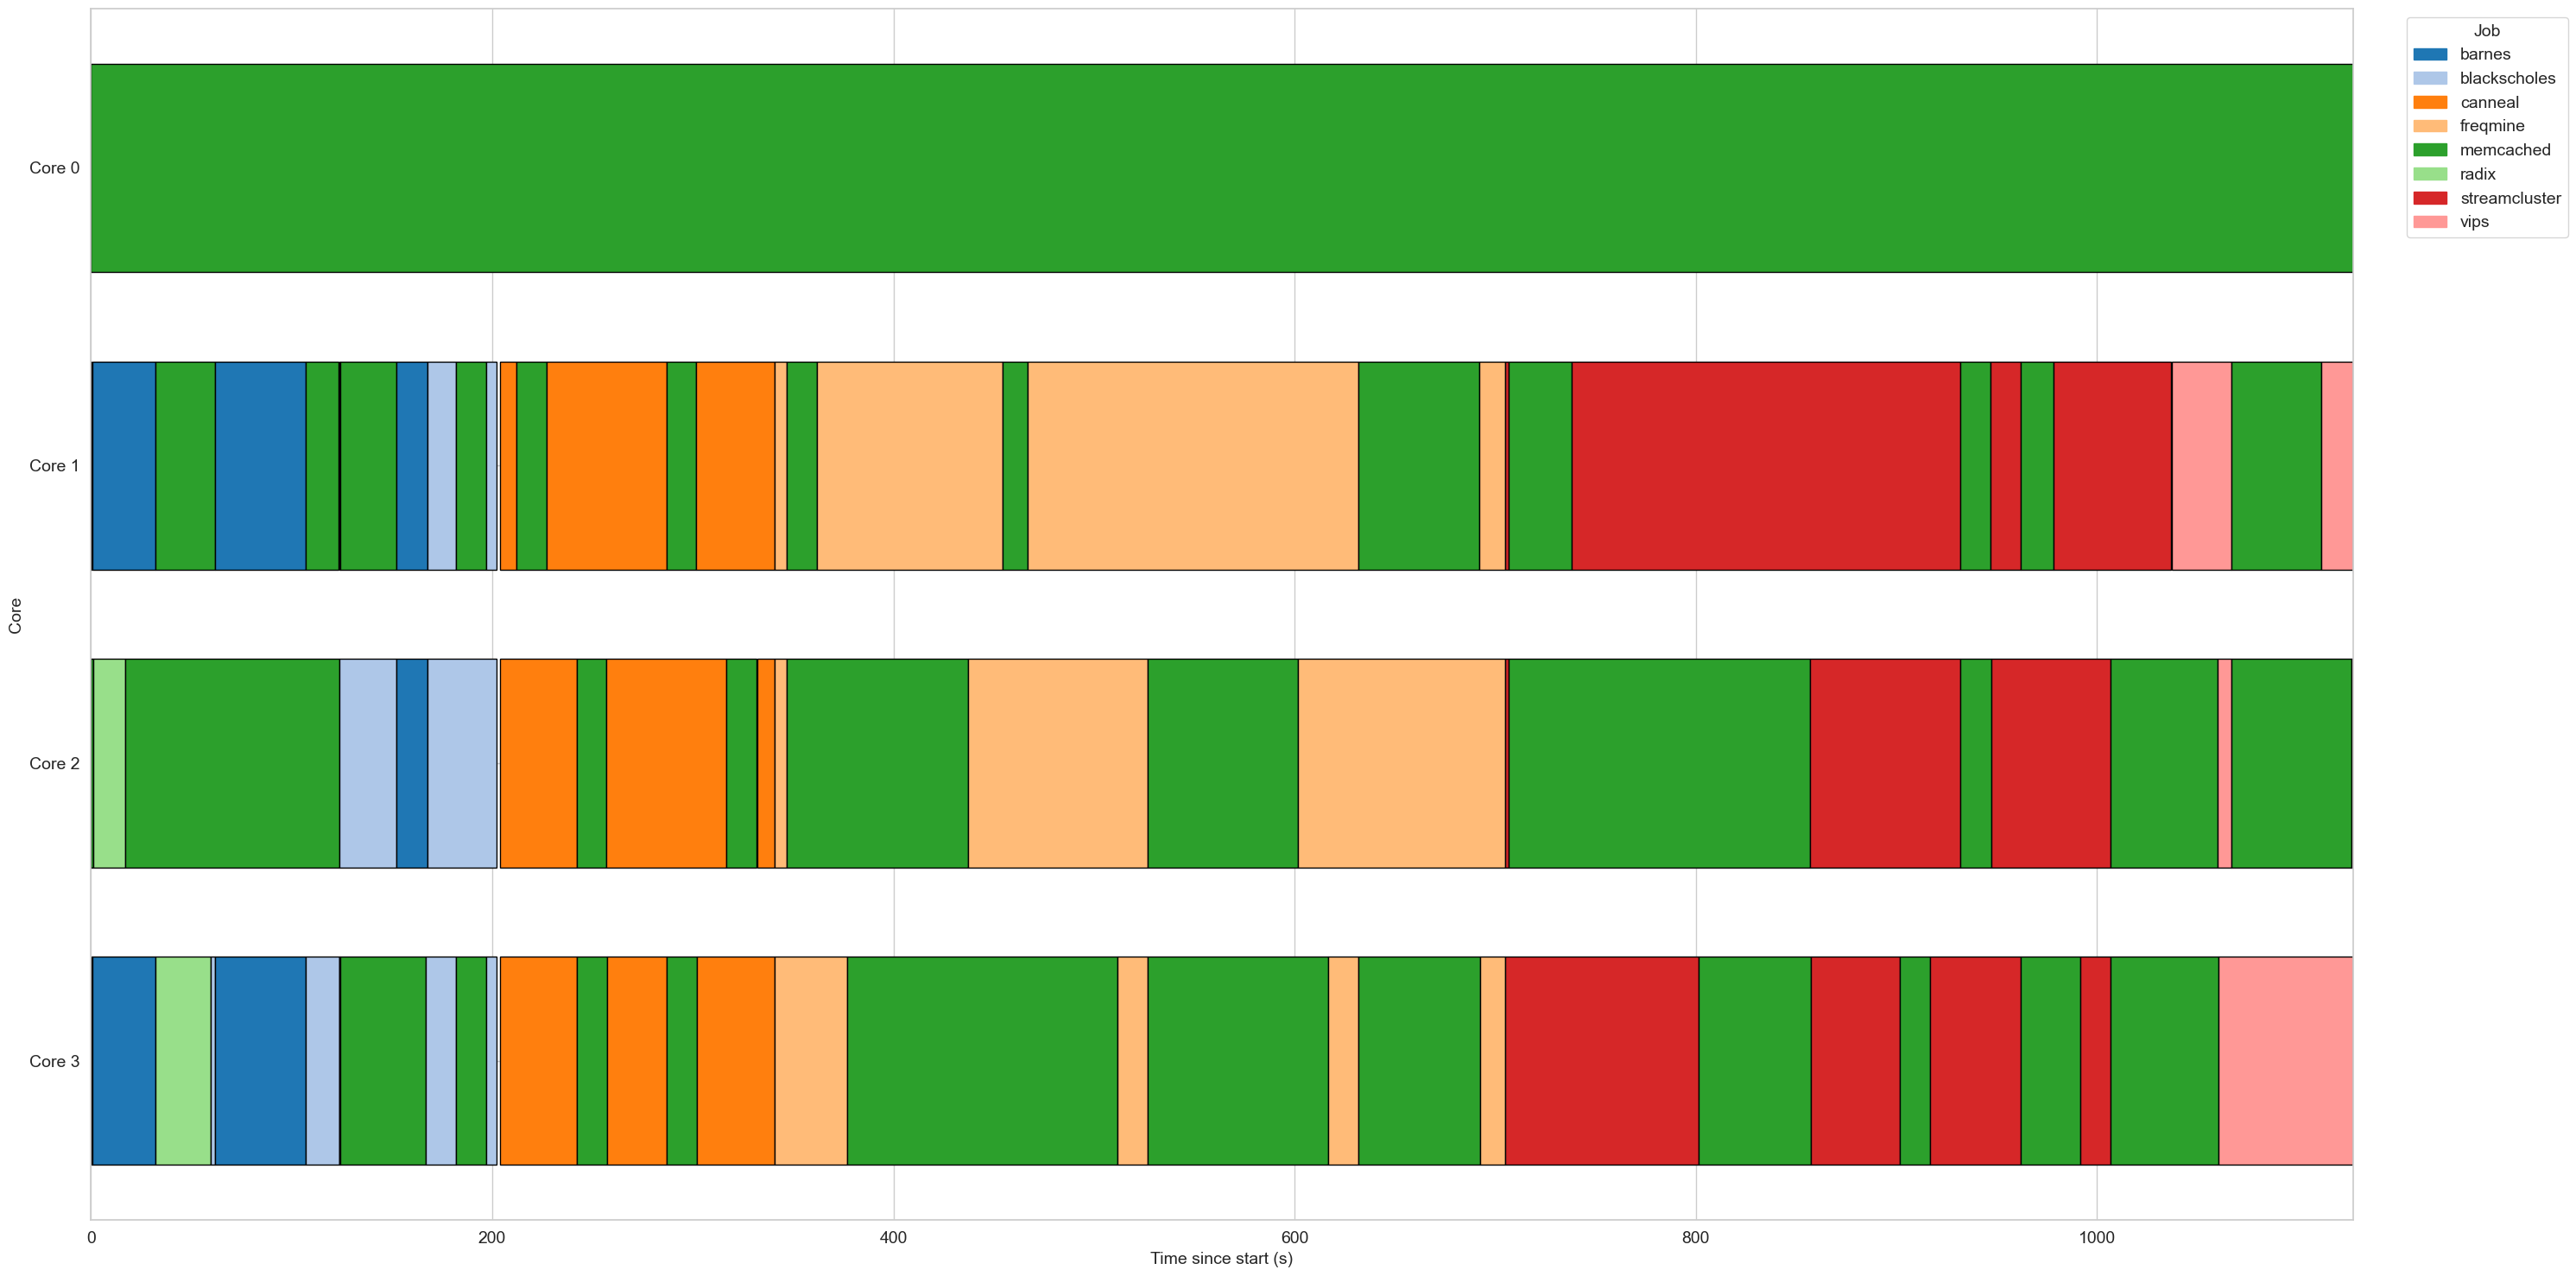

In [404]:
intervals_df = plot_core_schedule(events_df)

In [405]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_schedule_with_cpu(schedule_df, cpu_df, time_col="timestamp_ms_norm_s"):
    schedule_df = schedule_df.copy()
    cpu_df = cpu_df.copy()

    schedule_df["cores_list"] = schedule_df["cores"].apply(parse_cores)
    schedule_df = schedule_df.sort_values(time_col)
    cpu_df = cpu_df.sort_values(time_col)

    active = {}
    intervals = []
    last_known_cores = {}

    for _, row in schedule_df.iterrows():
        event = row["event"]
        job = row["job"]
        t = row[time_col]
        cores = row["cores_list"]

        if event in ["start", "update_cores", "unpause"]:
            if event == "unpause" and not cores:
                new_cores = last_known_cores.get(job, set())
            else:
                new_cores = set(cores)
                last_known_cores[job] = new_cores

            for (active_job, core), start_t in list(active.items()):
                if active_job == job and core not in new_cores:
                    intervals.append([active_job, core, start_t, t])
                    del active[(active_job, core)]

            for core in new_cores:
                if (job, core) not in active:
                    active[(job, core)] = t

        elif event in ["end", "pause"]:
            for (active_job, core), start_t in list(active.items()):
                if active_job == job:
                    intervals.append([active_job, core, start_t, t])
                    del active[(active_job, core)]

    last_t = schedule_df[time_col].max()
    for (job, core), start_t in active.items():
        intervals.append([job, core, start_t, last_t])

    intervals_df = pd.DataFrame(
        intervals,
        columns=["job", "core", "start", "end"]
    )

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(30, 20),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1]}
    )

    jobs = sorted(intervals_df["job"].unique())
    cmap = plt.get_cmap("tab20")
    job_colors = {job: cmap(i) for i, job in enumerate(jobs)}

    for _, row in intervals_df.iterrows():
        ax1.barh(
            y=row["core"],
            width=row["end"] - row["start"],
            left=row["start"],
            height=0.7,
            color=job_colors[row["job"]],
            edgecolor="black"
        )

    ax1.set_ylabel("Core")
    ax1.set_yticks([0, 1, 2, 3])
    ax1.set_yticklabels(["Core 0", "Core 1", "Core 2", "Core 3"])
    ax1.invert_yaxis()

    handles = [
        mpatches.Patch(color=job_colors[job], label=job)
        for job in jobs
    ]
    ax1.legend(handles=handles, title="Job", bbox_to_anchor=(1.02, 1), loc="upper left")

    # reshape CPU dataframe from wide to long format
    cpu_long = cpu_df.melt(
        id_vars=[time_col],
        value_vars=["cpu1", "cpu2", "cpu3", "cpu4"],
        var_name="cpu",
        value_name="utilization"
    )

    for cpu, group in cpu_long.groupby("cpu"):
        ax2.plot(
            group[time_col],
            group["utilization"],
            label=cpu
        )

    ax2.set_xlabel("Time since start (s)")
    ax2.set_ylabel("CPU utilization (%)")
    ax2.set_ylim(0, 105)
    ax2.legend(title="CPU", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    return intervals_df

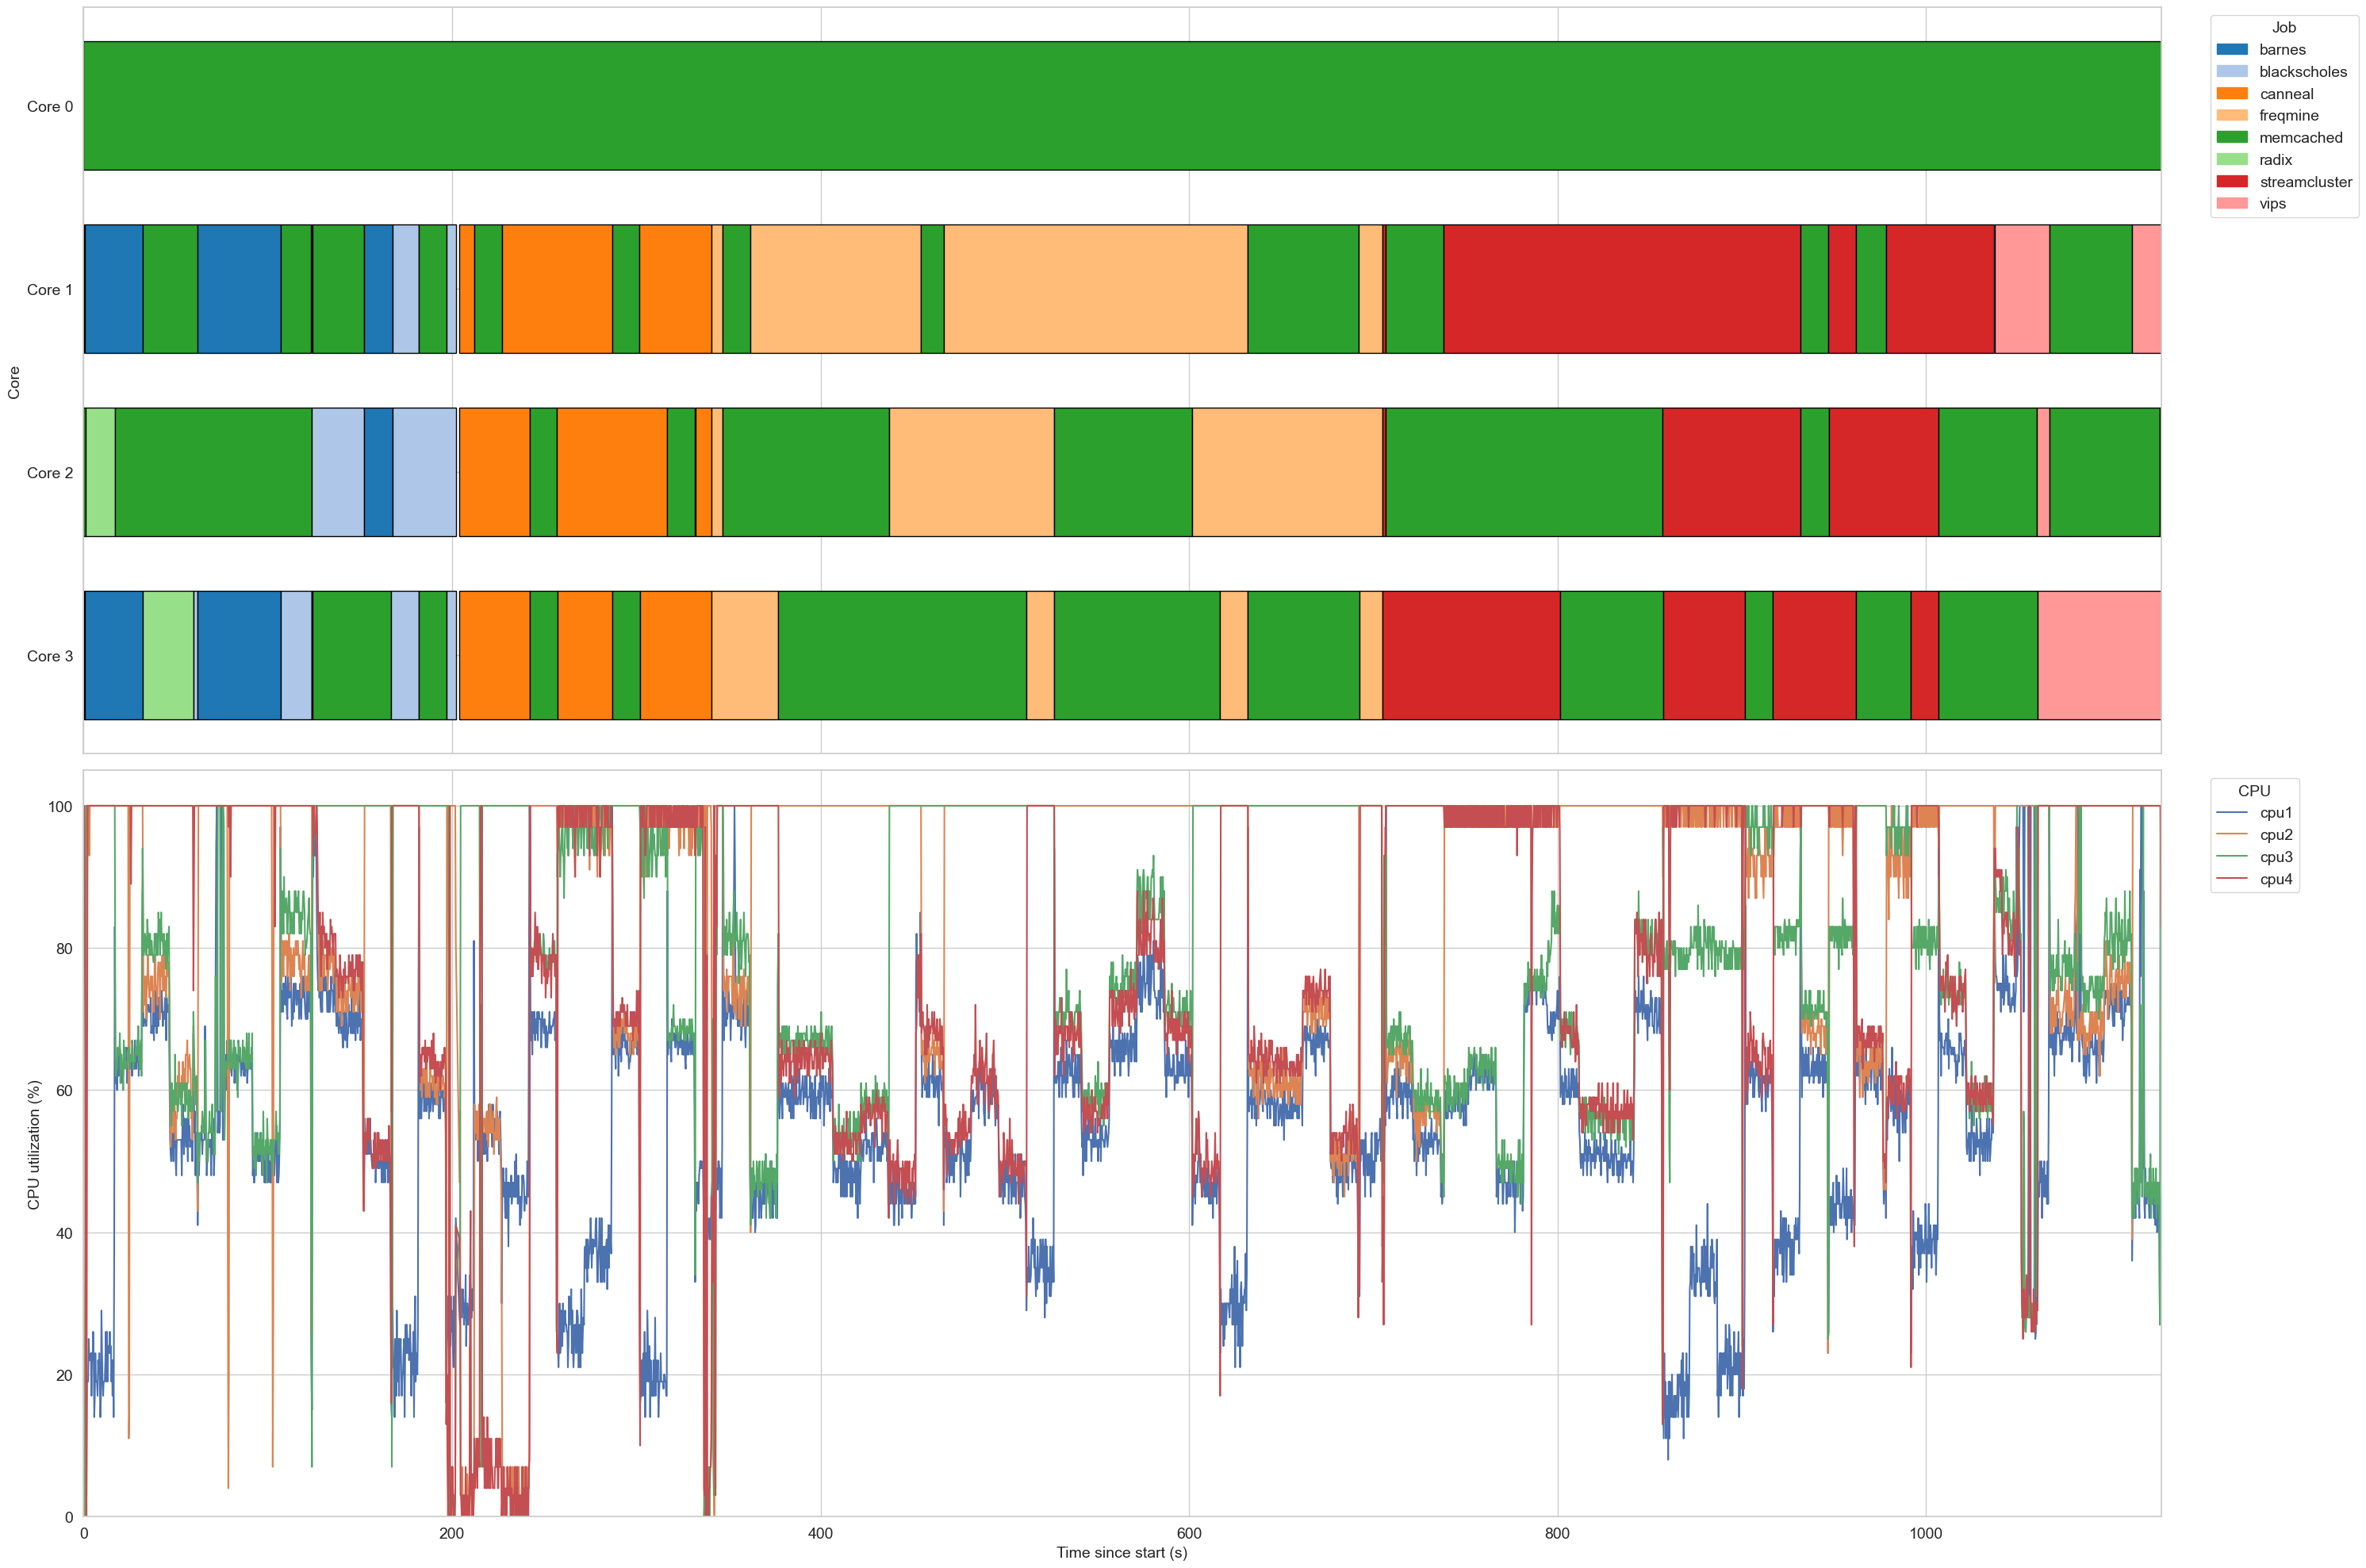

In [406]:
intervals_df = plot_schedule_with_cpu(events_df, cpu_df)

## Plot

In [339]:
def plot_full_timeline(events_df, cpu_df, perf_df,
                       time_col="timestamp_ms_norm_s"):

    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    events_df = events_df.copy()
    cpu_df = cpu_df.copy()
    perf_df = perf_df.copy()

    # ---------- Build job-core intervals ----------

    events_df["cores_list"] = events_df["cores"].apply(parse_cores)
    events_df = events_df.sort_values(time_col)

    active = {}
    intervals = []
    last_known_cores = {}

    for _, row in events_df.iterrows():
        event = row["event"]
        job = row["job"]
        t = row[time_col]
        cores = row["cores_list"]

        if event in ["start", "update_cores", "unpause"]:
            if event == "unpause" and not cores:
                new_cores = last_known_cores.get(job, set())
            else:
                new_cores = set(cores)
                last_known_cores[job] = new_cores

            for (active_job, core), start_t in list(active.items()):
                if active_job == job and core not in new_cores:
                    intervals.append([active_job, core, start_t, t])
                    del active[(active_job, core)]

            for core in new_cores:
                if (job, core) not in active:
                    active[(job, core)] = t

        elif event in ["end", "pause"]:
            for (active_job, core), start_t in list(active.items()):
                if active_job == job:
                    intervals.append([active_job, core, start_t, t])
                    del active[(active_job, core)]

    last_t = events_df[time_col].max()
    for (job, core), start_t in active.items():
        intervals.append([job, core, start_t, last_t])

    intervals_df = pd.DataFrame(
        intervals,
        columns=["job", "core", "start", "end"]
    )

    # ---------- Create figure with 3 shared plots ----------

    fig, (ax1, ax3, ax2) = plt.subplots(
        3, 1,
        figsize=(20, 15),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1]}
    )

    for ax in (ax1, ax2, ax3):
        ax.tick_params(axis="x", which="both", labelbottom=True)

    # ---------- Plot 1: Core schedule with striped overlaps ----------
    # cmap = plt.get_cmap("tab20")
    # job_colors = {job: cmap(i) for i, job in enumerate(jobs)}
    job_colors = {
        "barnes": "#AACCCA",
        "blackscholes": "#CCA000",
        "canneal": "#CCCCAA",
        "freqmine": "#0CCA00",
        "radix": "#00CCA0",
        "streamcluster": "#CCACCA",
        "vips": "#CC0A00",
        "memcached": "#808080"
    }
    intervals_df["job"] = (
        intervals_df["job"]
        .str.replace("parsec-", "", regex=False)
    )

    jobs = sorted(intervals_df["job"].unique())

    def draw_striped_bar(ax, y, start, end, jobs_active, height=0.7, n_stripes=30):
        """
        Draw one horizontal bar segment with alternating vertical stripes.
        jobs_active: list of job names active in this segment
        """
        width = end - start
        if width <= 0:
            return

        stripe_width = width / n_stripes

        for i in range(n_stripes):
            job = jobs_active[i % len(jobs_active)]
            x0 = start + i * stripe_width

            ax.barh(
                y=y,
                width=stripe_width,
                left=x0,
                height=height,
                color=job_colors[job],
                edgecolor=None
            )

        # Draw one border around the whole striped segment
        ax.barh(
            y=y,
            width=width,
            left=start,
            height=height,
            color="none",
            edgecolor="black",
            linewidth=1
        )


    # Build atomic non-overlapping segments per core
    for core, core_df in intervals_df.groupby("core"):
        core_df = core_df.sort_values("start")

        # all interval boundaries on this core
        boundaries = sorted(
            set(core_df["start"]).union(set(core_df["end"]))
        )

        for start, end in zip(boundaries[:-1], boundaries[1:]):
            if end <= start:
                continue

            # jobs active during this atomic segment
            active_jobs = core_df[
                (core_df["start"] < end) &
                (core_df["end"] > start)
            ]["job"].unique()

            if len(active_jobs) == 0:
                continue

            elif len(active_jobs) == 1:
                job = active_jobs[0]
                ax1.barh(
                    y=core,
                    width=end - start,
                    left=start,
                    height=0.7,
                    color=job_colors[job],
                    edgecolor="black"
                )

            else:
                draw_striped_bar(
                    ax=ax1,
                    y=core,
                    start=start,
                    end=end,
                    jobs_active=list(active_jobs),
                    height=0.7,
                    n_stripes=40
                )

    ax1.set_ylabel("Core")
    ax1.set_yticks([0, 1, 2, 3])
    ax1.invert_yaxis()

    handles = [
        mpatches.Patch(color=job_colors[j], label=j)
        for j in jobs
    ]

    ax1.legend(
        handles=handles,
        title="Job",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    # ---------- Plot 3: CPU utilization ----------

    cpu_long = cpu_df.melt(
        id_vars=[time_col],
        value_vars=["cpu1","cpu2","cpu3","cpu4"],
        var_name="cpu",
        value_name="util"
    )

    cpu_styles = {
        "cpu1": {"linestyle": ":",  "marker": "o"},
        "cpu2": {"linestyle": "-", "marker": "s"},
        "cpu3": {"linestyle": "--",  "marker": "^"},
        "cpu4": {"linestyle": "-.", "marker": "D"},
    }

    for cpu, group in cpu_long.groupby("cpu"):
        style = cpu_styles.get(cpu, {})

        ax2.plot(
            group[time_col],
            group["util"],
            label=cpu,
            # linestyle=style.get("linestyle", "-"),
            marker=style.get("marker", None),
            markersize=2
        )

    ax2.set_ylabel("CPU util (%)")
    ax2.set_ylim(0,105)

    ax2.legend(
        title="CPU",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    # ---------- Plot 2: p95 + QPS ----------

    ax3_right = ax3.twinx()

    # p95 (left axis)
    ax3.plot(
        perf_df[time_col],
        perf_df["p95"],
        label="p95",
        linewidth=2
    )

    # ---------- SLO line ----------
    slo_value = 0.8

    ax3.axhline(
        y=slo_value,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax3.text(
        500,          # x-position
        0.790,        # y-position
        "SLO",
        color="black",
        ha="center",
        va="top",
        fontsize=12
    )

    # QPS (right axis)
    ax3_right.plot(
        perf_df[time_col],
        perf_df["QPS"],
        label="QPS",
        linestyle=":",
        linewidth=2,
        color="orange"
    )

    ax3.set_ylabel("p95 latency (ms)")
    ax3_right.set_ylabel("QPS")

    # Combined legend
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_right.get_legend_handles_labels()

    ax3.legend(
        lines1 + lines2,
        labels1 + labels2,
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    ax2.set_xlabel("Time (s)")

    ax2.set_xlim(-2, 900)

    plt.tight_layout()
    plt.savefig(plotting_path, bbox_inches="tight")
    plt.show()

    return intervals_df

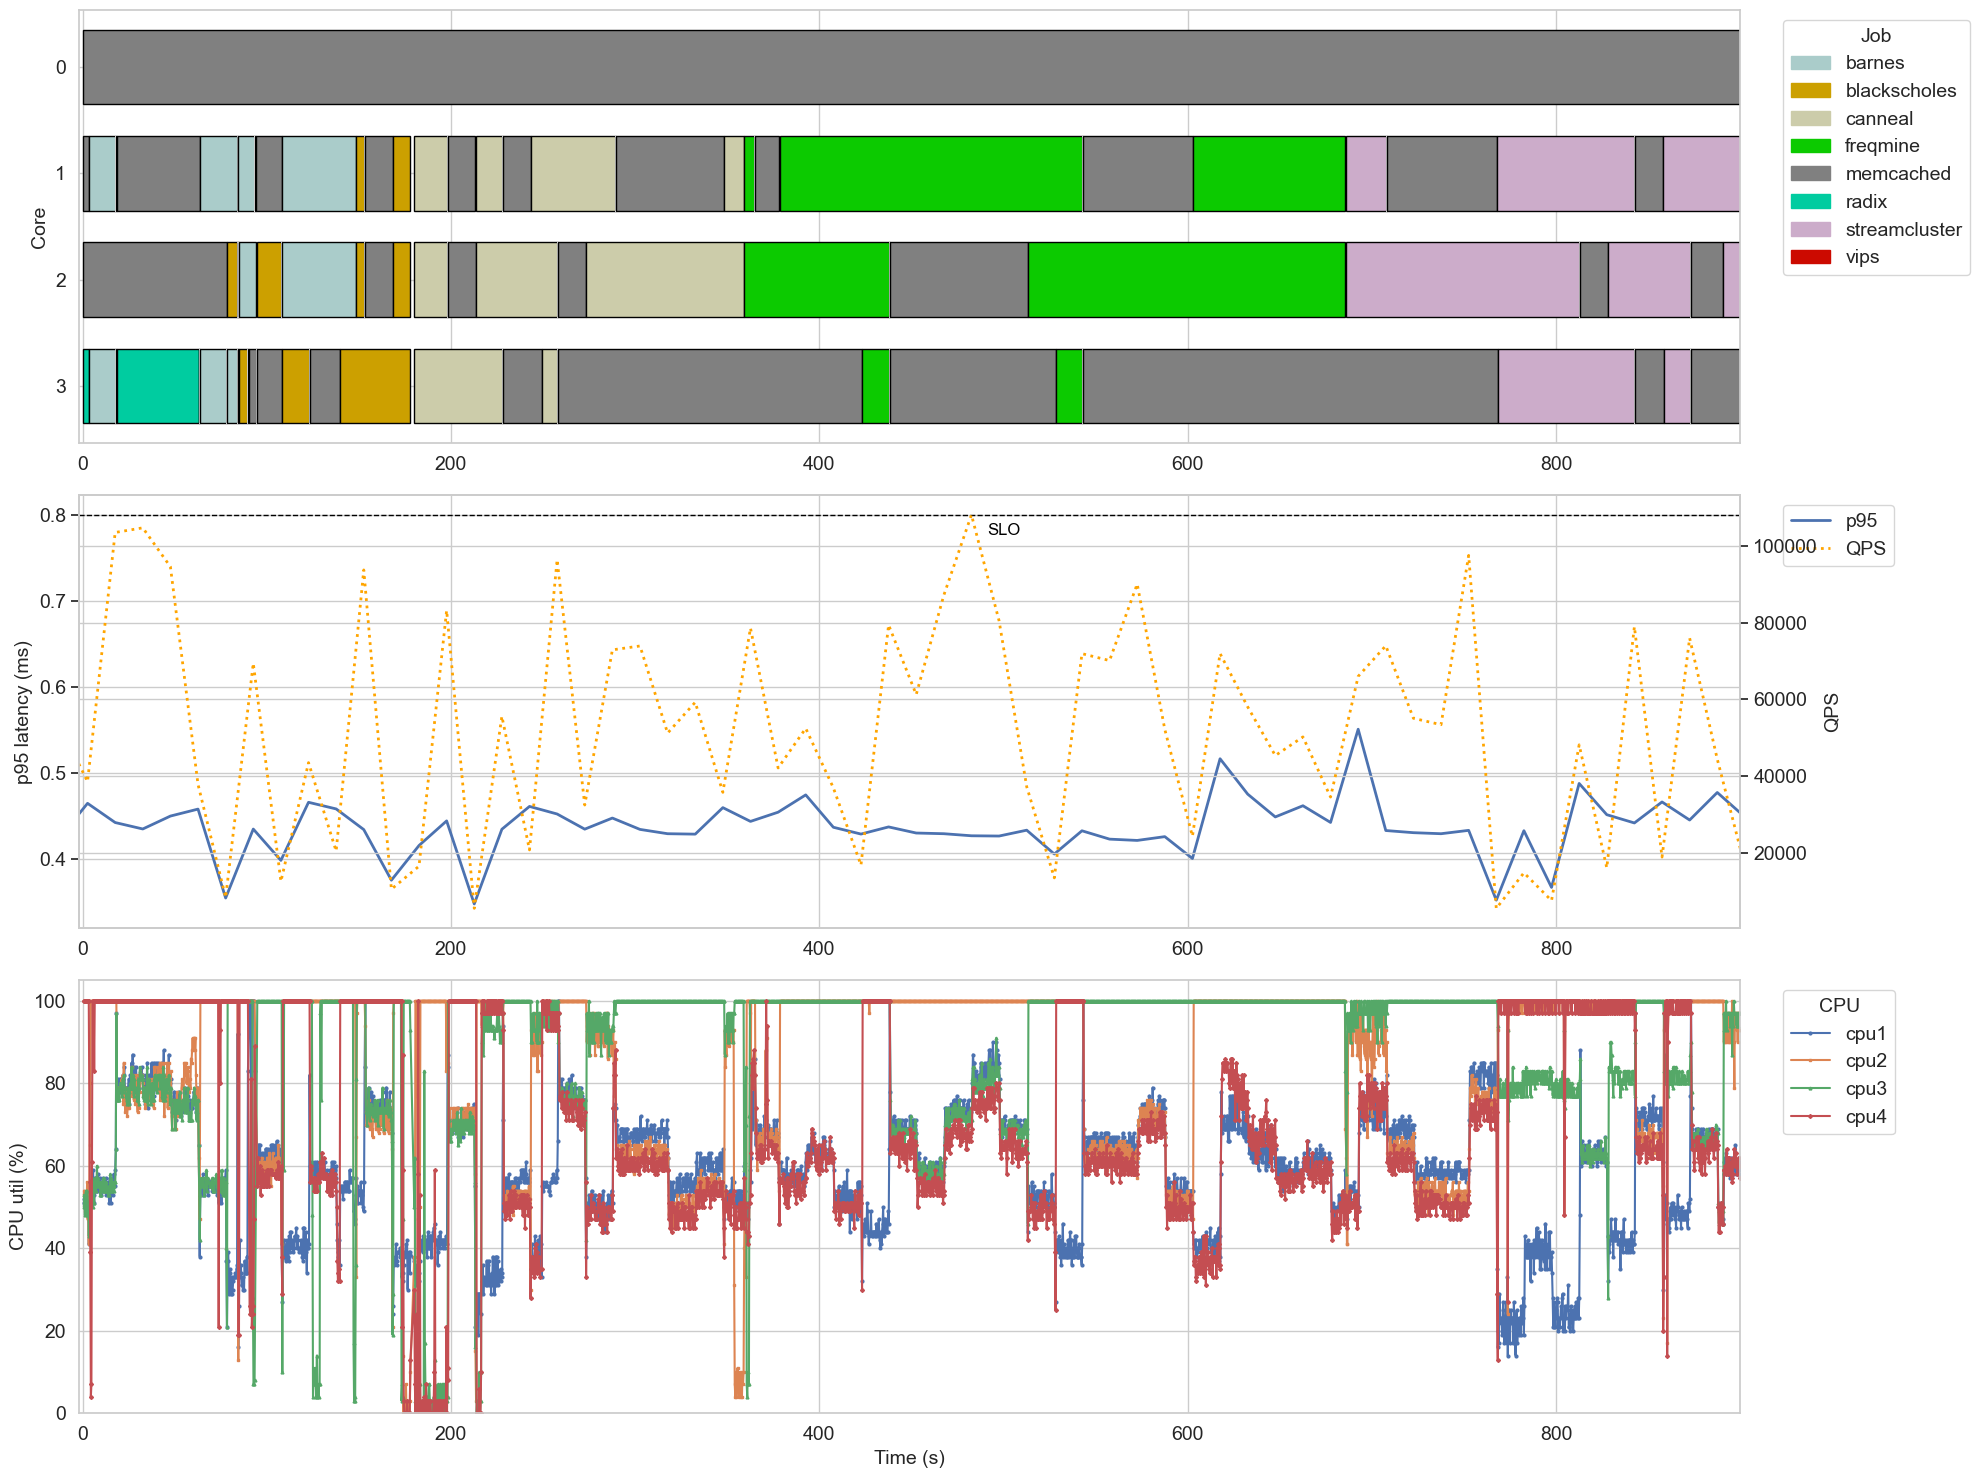

In [340]:
intervals_df = plot_full_timeline(
    events_df,
    cpu_df,
    mcperf_df
)

In [341]:
events_df

,timestamp,event,job,cores,timestamp_ms,timestamp_ms_norm_ms,timestamp_ms_norm_s
0,2026-05-10 10:42:08.215938,update_cores,memcached,"[0,1,2]",1778409728215,0,0.000
1,2026-05-10 10:42:08.215978,start,memcached,"[0, 1, 2]",1778409728215,0,0.000
2,2026-05-10 10:42:08.443852,start,radix,[3],1778409728443,228,0.228
3,2026-05-10 10:42:11.479506,update_cores,memcached,"[0,2]",1778409731479,3264,3.264
4,2026-05-10 10:42:11.499999,pause,radix,,1778409731499,3284,3.284
...,...,...,...,...,...,...,...
131,2026-05-10 10:59:33.637585,update_cores,vips,"[1,2,3]",1778410773637,1045422,1045.422
132,2026-05-10 10:59:41.478590,update_cores,memcached,"[0,1,2]",1778410781478,1053263,1053.263
133,2026-05-10 10:59:41.498587,update_cores,vips,[3],1778410781498,1053283,1053.283
134,2026-05-10 11:00:03.785202,end,vips,,1778410803785,1075570,1075.570


In [342]:
def plot_full_timeline_areas(events_df, cpu_df, perf_df,
                       time_col="timestamp_ms_norm_s"):
    
    mpl.rcParams.update({
        "font.size": 14,          # base size (+~3 from default 12)
        "axes.titlesize": 18,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "legend.title_fontsize": 14,
    })

    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    events_df = events_df.copy()
    cpu_df = cpu_df.copy()
    perf_df = perf_df.copy()

    # ---------- Build job-core intervals ----------

    events_df["cores_list"] = events_df["cores"].apply(parse_cores)
    events_df = events_df.sort_values(time_col)

    active = {}
    intervals = []
    last_known_cores = {}

    for _, row in events_df.iterrows():
        event = row["event"]
        job = row["job"]
        t = row[time_col]
        cores = row["cores_list"]

        if event in ["start", "update_cores", "unpause"]:
            if event == "unpause" and not cores:
                new_cores = last_known_cores.get(job, set())
            else:
                new_cores = set(cores)
                last_known_cores[job] = new_cores

            for (active_job, core), start_t in list(active.items()):
                if active_job == job and core not in new_cores:
                    intervals.append([active_job, core, start_t, t])
                    del active[(active_job, core)]

            for core in new_cores:
                if (job, core) not in active:
                    active[(job, core)] = t

        elif event in ["end", "pause"]:
            for (active_job, core), start_t in list(active.items()):
                if active_job == job:
                    intervals.append([active_job, core, start_t, t])
                    del active[(active_job, core)]

    last_t = events_df[time_col].max()
    for (job, core), start_t in active.items():
        intervals.append([job, core, start_t, last_t])

    intervals_df = pd.DataFrame(
        intervals,
        columns=["job", "core", "start", "end"]
    )

    # ---------- Create figure with 3 shared plots ----------

    fig, (ax1, ax3, ax2) = plt.subplots(
        3, 1,
        figsize=(16, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1]}
    )

    for ax in (ax1, ax2, ax3):
        ax.tick_params(axis="x", which="both", labelbottom=True)

    # ---------- Plot 1: Core schedule with striped overlaps ----------
    # cmap = plt.get_cmap("tab20")
    # job_colors = {job: cmap(i) for i, job in enumerate(jobs)}
    job_colors = {
        "barnes": "#AACCCA",
        "blackscholes": "#CCA000",
        "canneal": "#CCCCAA",
        "freqmine": "#0CCA00",
        "radix": "#00CCA0",
        "streamcluster": "#CCACCA",
        "vips": "#CC0A00",
        "memcached": "#808080"
    }
    intervals_df["job"] = (
        intervals_df["job"]
        .str.replace("parsec-", "", regex=False)
    )

    jobs = sorted(intervals_df["job"].unique())

    def draw_striped_bar(ax, y, start, end, jobs_active, height=0.7, n_stripes=30):
        """
        Draw one horizontal bar segment with alternating vertical stripes.
        jobs_active: list of job names active in this segment
        """
        width = end - start
        if width <= 0:
            return

        stripe_width = width / n_stripes

        for i in range(n_stripes):
            job = jobs_active[i % len(jobs_active)]
            x0 = start + i * stripe_width

            ax.barh(
                y=y,
                width=stripe_width,
                left=x0,
                height=height,
                color=job_colors[job],
                edgecolor=None
            )

        # Draw one border around the whole striped segment
        ax.barh(
            y=y,
            width=width,
            left=start,
            height=height,
            color="none",
            edgecolor="black",
            linewidth=1
        )


    # Build atomic non-overlapping segments per core
    for core, core_df in intervals_df.groupby("core"):
        core_df = core_df.sort_values("start")

        # all interval boundaries on this core
        boundaries = sorted(
            set(core_df["start"]).union(set(core_df["end"]))
        )

        for start, end in zip(boundaries[:-1], boundaries[1:]):
            if end <= start:
                continue

            # jobs active during this atomic segment
            active_jobs = core_df[
                (core_df["start"] < end) &
                (core_df["end"] > start)
            ]["job"].unique()

            if len(active_jobs) == 0:
                continue

            elif len(active_jobs) == 1:
                job = active_jobs[0]
                ax1.barh(
                    y=core,
                    width=end - start,
                    left=start,
                    height=0.7,
                    color=job_colors[job],
                    edgecolor="black"
                )

            else:
                draw_striped_bar(
                    ax=ax1,
                    y=core,
                    start=start,
                    end=end,
                    jobs_active=list(active_jobs),
                    height=0.7,
                    n_stripes=40
                )

    # ax1.set_ylabel("Core")
    ax1.set_ylabel(
        "Core on the Machine",
        rotation=0,     # horizontal
        labelpad=150,    # move away from axis
        ha="left",
        va="bottom"
    )
    ax1.yaxis.set_label_coords(-0.028, 1.04)

    ax1.set_yticks([0, 1, 2, 3])
    ax1.invert_yaxis()

    handles = [
        mpatches.Patch(color=job_colors[j], label=j)
        for j in jobs
    ]

    ax1.legend(
        handles=handles,
        title="Job",
        bbox_to_anchor=(1.17, 1),
        loc="upper right"
    )


    # ---------- Plot 3: CPU utilization as stacked area ----------

    cpu_cols = ["cpu1", "cpu2", "cpu3", "cpu4"]

    ax2.stackplot(
        cpu_df[time_col],
        [cpu_df[c] for c in cpu_cols],
        labels=cpu_cols,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5
    )

    # ax2.set_ylabel("CPU util (%)")
    ax2.set_ylabel(
        "CPU Utilization (%)",
        rotation=0,     # horizontal
        labelpad=150,    # move away from axis
        ha="left",
        va="bottom"
    )
    ax2.yaxis.set_label_coords(-0.028, 1.04)
    ax2.set_ylim(0, 400)

    ax2.legend(
        title="CPU",
        bbox_to_anchor=(1.17, 1),
        loc="upper right"
    )

    # ---------- Plot 2: p95 + QPS ----------

    ax3_right = ax3.twinx()

    # p95 (left axis)
    # ax3.plot(
    #     perf_df[time_col],
    #     perf_df["p95"],
    #     label="p95",
    #     linestyle="--",
    #     linewidth=2
    # )
    ax3.bar(
        perf_df[time_col],
        perf_df["p95"],
        width=14.9,
        align="edge",      # bar starts at timestamp
        label="p95",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.5
    )

    # ---------- SLO line ----------
    slo_value = 0.8

    ax3.axhline(
        y=slo_value,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax3.text(
        445,          # x-position
        0.82,        # y-position
        "SLO",
        color="black",
        ha="center",
        va="bottom",
        fontsize=14
    )

    # QPS (right axis)
    # ax3_right.plot(
    #     perf_df[time_col],
    #     perf_df["QPS"],
    #     label="QPS",
    #     linestyle="-",
    #     linewidth=2,
    #     color="orange"
    # )

    ax3_right.step(
        perf_df[time_col],
        perf_df["QPS"],
        where="post",   # value stays constant until next timestamp
        label="QPS",
        linewidth=2,
        color="orange"
    )

    # ax3.set_ylabel("p95 latency (ms)")
    ax3.set_ylabel(
        "95th Percentile Latency (ms)",
        rotation=0,     # horizontal
        labelpad=150,    # move away from axis
        ha="left",
        va="bottom"
    )
    ax3.yaxis.set_label_coords(-0.028, 1.04)
    
    
    # ax3_right.set_ylabel("QPS")
    ax3_right.set_ylabel(
        "QPS",
        rotation=0,     # horizontal
        labelpad=150,    # move away from axis
        ha="right",
        va="bottom"
    )
    ax3_right.yaxis.set_label_coords(1.028, 1.04)

    ### align axis ###
    ax3.set_ylim(0, 1)
    left_ticks = np.linspace(0, 1, 6)

    # Choose left-axis ticks
    # left_ticks = ax3.get_yticks()
    ax3.set_yticks(left_ticks)

    # Right axis
    ax3_right.set_ylim(0, 125000)

    # Map left tick positions proportionally onto right axis
    left_min, left_max = ax3.get_ylim()
    right_min, right_max = ax3_right.get_ylim()

    right_ticks = (
        (left_ticks - left_min) / (left_max - left_min)
        * (right_max - right_min)
        + right_min
    )

    ax3_right.set_yticks(right_ticks)

    ax3.grid(True)
    ax3_right.grid(False)
    ###

    # Combined legend
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_right.get_legend_handles_labels()

    ax3.legend(
        lines1 + lines2,
        labels1 + labels2,
        bbox_to_anchor=(1.17, 1),
        loc="upper right"
    )

    ax1.set_xlabel("Time (s)", labelpad=5)
    ax2.set_xlabel("Time (s)", labelpad=5)
    ax3.set_xlabel("Time (s)", labelpad=5)

    ax2.set_xlim(-2, 1200)

    ax1.set_title(
        f"Results of our Dynamic Scheduling Policy",
        fontsize=20,
        pad=25,
        x=0.167
        # x=0.228
    )

    plt.tight_layout()
    plt.savefig(plotting_path, bbox_inches="tight")
    plt.show()

    return intervals_df

## Final Plot

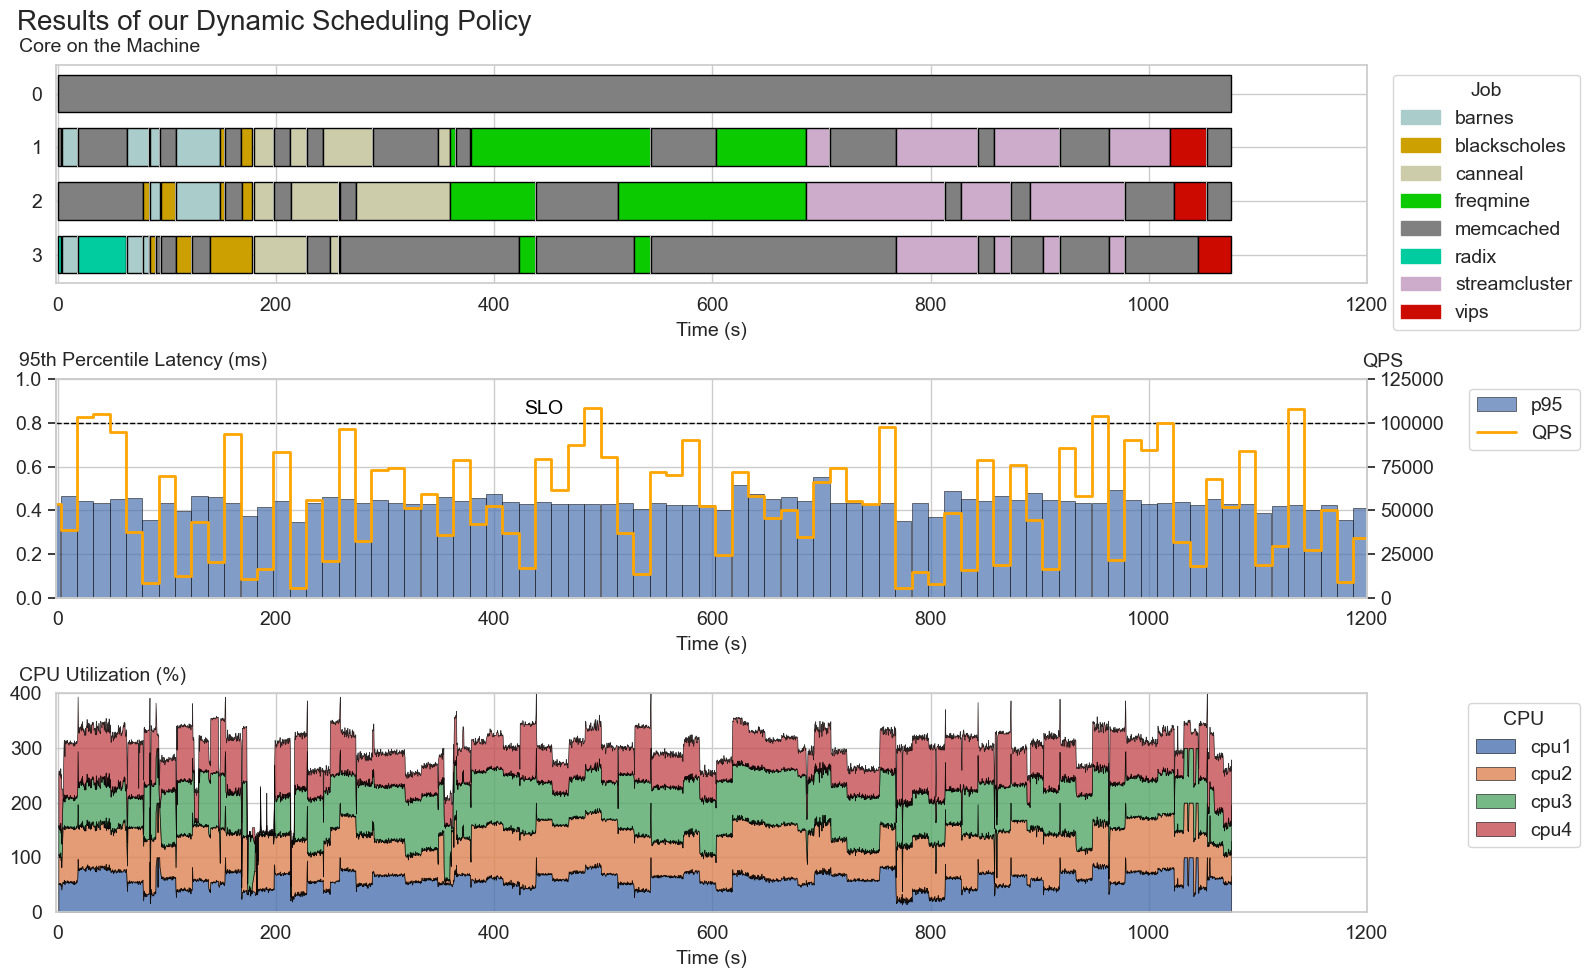

In [343]:
intervals_df = plot_full_timeline_areas(
    events_df,
    cpu_df,
    mcperf_df
)

In [407]:
events_df.to_csv("results/q3/run2.csv")

In [ ]:
df1 = pd.read_csv("results/q3/run1.csv")
df2 = pd.read_csv("results/q3/run2.csv")
df3 = pd.read_csv("results/q3/run3.csv")

events1 = df1.sort_values(["timestamp_ms", "Unnamed: 0"])
events2 = df2.sort_values(["timestamp_ms", "Unnamed: 0"])
events3 = df3.sort_values(["timestamp_ms", "Unnamed: 0"])

def active_time_ms(g):
    active = False
    last = None
    total = 0

    for _, r in g.iterrows():
        t, ev = r["timestamp_ms"], r["event"]

        if ev == "start":
            active = True
            last = t

        elif ev == "pause" and active:
            total += t - last
            active = False

        elif ev == "unpause" and not active:
            active = True
            last = t

        elif ev == "end" and active:
            total += t - last
            active = False

    return total

result1 = (
    events1[events1["event"].isin(["start", "pause", "unpause", "end"])]
    .groupby("job")
    .apply(active_time_ms, include_groups=False)
    .rename("active_ms")
    .reset_index()
)

result2 = (
    events2[events2["event"].isin(["start", "pause", "unpause", "end"])]
    .groupby("job")
    .apply(active_time_ms, include_groups=False)
    .rename("active_ms")
    .reset_index()
)

result3 = (
    events3[events3["event"].isin(["start", "pause", "unpause", "end"])]
    .groupby("job")
    .apply(active_time_ms, include_groups=False)
    .rename("active_ms")
    .reset_index()
)

result1["active_s"] = result1["active_ms"] / 1000
result2["active_s"] = result2["active_ms"] / 1000
result3["active_s"] = result3["active_ms"] / 1000

,job,active_ms,active_s
0,barnes,94815,94.815
1,blackscholes,79750,79.750
2,canneal,131192,131.192
3,freqmine,360617,360.617
4,memcached,0,0.000
5,radix,45646,45.646
6,streamcluster,333869,333.869
7,vips,89614,89.614


In [414]:
combined = pd.concat([result1, result2, result3], ignore_index=True)

stats = (
    combined
    .groupby("job")["active_s"]
    .agg(["mean", "std"])
    .reset_index()
)

stats

,job,mean,std
0,barnes,90.940333,5.001646
1,blackscholes,80.231000,1.693530
2,canneal,149.184667,26.341122
3,freqmine,350.329333,20.826398
4,memcached,0.000000,0.000000
5,radix,45.747333,1.927998
6,streamcluster,333.171333,1.011724
7,vips,78.542667,19.722476


In [418]:
timestamp1 = max(df1["timestamp_ms_norm_s"])
timestamp2 = max(df2["timestamp_ms_norm_s"])
timestamp3 = max(df3["timestamp_ms_norm_s"])

mean = np.mean([timestamp1, timestamp2, timestamp3])
std = np.std([timestamp1, timestamp2, timestamp3])  

print(mean)
print(std)

1107.168
22.652348678816246
